## Analysis of Fitbit User Behavior for Bellabeat
    
<h3>Kevin Alexis Sotelo Guzmán</h3>

<h3>07/07/2025</h3>

<h3>Python</h3>

# 1. Ask

- Bellabeat Background:

Urška Sršen and Sando Mur founded Bellabeat, a high-tech company that develops smart wellness products. Drawing on her background as an artist, Sršen helped create beautifully designed technology that informs and inspires women around the world. By collecting data on physical activity, sleep, stress, and reproductive health, Bellabeat empowers women with valuable insights into their health and daily habits. Since its founding in 2013, Bellabeat has grown rapidly and established itself as a technology-driven wellness company focused on women.

- Business Problem:

Bellabeat aims to understand how consumers use smart devices in order to identify growth opportunities and develop more effective marketing strategies.

- Stakeholders:

Urška Sršen – Co-founder and Chief Creative Officer

Sando Mur – Co-founder

Marketing Team – Responsible for developing marketing campaigns.

Executive Team – Responsible for strategic decision-making.

- General Objective:

Analyze the physical activity habits of Fitbit users to generate strategic recommendations for Bellabeat.

- Specific Objectives:

Analyze daily physical activity.
Identify weekly activity patterns.
Examine the relationship between daily steps and calories burned.
Classify users based on their activity levels.
Develop business recommendations.

- Business Questions:

What are the current trends in smart device usage?

How can these trends be applied to Bellabeat?

How can these insights influence Bellabeat's marketing strategy?

# 2. Prepare

- Dataset:

The data source used for this case study is the FitBit Fitness Tracker Data dataset. This dataset is hosted on Kaggle, was shared by Mobius, and was generated from survey responses collected through Amazon Mechanical Turk between March 12, 2016, and May 12, 2016.

- Data Accessibility and Privacy:

The dataset is published under the CC0 (Public Domain) license, which means that the author has waived all copyright and related rights to the extent permitted by law. This allows the dataset to be copied, modified, distributed, and used, including for commercial purposes, without requiring permission.

- Data Organization and Verification:

The dataset consists of 18 CSV files: 15 in long format and 3 in wide format.

The files contain a wide variety of information related to users' physical activity, including:

Physical activity metrics.

Calories burned.

Sleep records.

Metabolic equivalents of tasks (METs).

Heart rate.

Step count.

The data is recorded at different time intervals: seconds, minutes, hours, and days.

- Data Limitations:

This dataset has several limitations that may affect the results of the analysis. The main limitations include:

It does not include demographic information about the participants.
The sample size is relatively small (33 participants).
The data collection period is short (approximately two months).

These limitations should be taken into account when interpreting the results and developing conclusions and recommendations for Bellabeat.

# 3. Process

Tools: Python, pandas, numpy

Loading libraries and importing the data:

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import datetime as dt
import seaborn as sns

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub

/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteCaloriesNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/weightLogInfo_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteMETsNarrow_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyCalories_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/heartrate_seconds_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/minuteSleep_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitabase Data 3.12.16-4.11.16/hourlyIntensities_merged.csv
/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_3.12.16-4.11.16/Fitaba

First, I imported the dailyActivity_merged.csv dataset using the pd.read_csv() function from the pandas library.

In [2]:
# Prepare data
df = pd.read_csv('/kaggle/input/datasets/arashnic/fitbit/mturkfitbit_export_4.12.16-5.12.16/Fitabase Data 4.12.16-5.12.16/dailyActivity_merged.csv')

Once the dataset is loaded, let's first check how many rows and columns it contains using the pandas .shape attribute.


In [3]:
df.shape

(940, 15)

It can be observed that the dataset contains 940 rows and 15 columns. Now, let's check the column names using the .columns attribute from the pandas library.

In [4]:
df.columns

Index(['Id', 'ActivityDate', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
       'LoggedActivitiesDistance', 'VeryActiveDistance',
       'ModeratelyActiveDistance', 'LightActiveDistance',
       'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes',
       'LightlyActiveMinutes', 'SedentaryMinutes', 'Calories'],
      dtype='object')

In [5]:
df.head(10)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863
5,1503960366,4/17/2016,9705,6.48,6.48,0.0,3.19,0.78,2.51,0.0,38,20,164,539,1728
6,1503960366,4/18/2016,13019,8.59,8.59,0.0,3.25,0.64,4.71,0.0,42,16,233,1149,1921
7,1503960366,4/19/2016,15506,9.88,9.88,0.0,3.53,1.32,5.03,0.0,50,31,264,775,2035
8,1503960366,4/20/2016,10544,6.68,6.68,0.0,1.96,0.48,4.24,0.0,28,12,205,818,1786
9,1503960366,4/21/2016,9819,6.34,6.34,0.0,1.34,0.35,4.65,0.0,19,8,211,838,1775


The dataset stores and records the information collected daily by Fitbit physical activity tracking devices, such as smartwatches and fitness applications. Based on a quick review, we can summarize the columns as follows:

- Id: Unique identifier for each survey participant user.
- ActivityDate: Date corresponding to the activity record.
- TotalSteps: Total number of steps taken by the user during that day.
- TotalDistance: Total distance traveled by the user during the day.
- TrackerDistance: Distance recorded by the tracking device.
- LoggedActivitiesDistance: Distance recorded by the device during specific activities.
- VeryActiveDistance: Distance traveled during very high-intensity activities.
- ModeratelyActiveDistance: Distance traveled during moderate-intensity activities.
- LightActiveDistance: Distance traveled during light-intensity activities.
- SedentaryActiveDistance: Distance traveled during sedentary activity periods.
- VeryActiveMinutes: Minutes spent on very high-intensity activities.
- FairlyActiveMinutes: Minutes spent on moderate-intensity activities.
- LightlyActiveMinutes: Minutes spent on light-intensity activities.
- SedentaryMinutes: Minutes during which the user remained sedentary.
- Calories: Amount of calories burned during that day.

Once the columns have been reviewed and the information contained in the dataset is understood, we can begin the data cleaning process.


**Data cleaning**

The first step in the cleaning process is to verify that the data types of each column are consistent with the content and purpose of the information they store. To do this, we will use the pandas .dtypes attribute, which allows us to identify the data type associated with each column.

In [6]:
df.dtypes

Id                            int64
ActivityDate                 object
TotalSteps                    int64
TotalDistance               float64
TrackerDistance             float64
LoggedActivitiesDistance    float64
VeryActiveDistance          float64
ModeratelyActiveDistance    float64
LightActiveDistance         float64
SedentaryActiveDistance     float64
VeryActiveMinutes             int64
FairlyActiveMinutes           int64
LightlyActiveMinutes          int64
SedentaryMinutes              int64
Calories                      int64
dtype: object

We can observe that the Id column is stored as an integer (int), although in this case it would be more appropriate to treat it as a text string (string or object). This is because the Id functions only as a unique identifier for each user and is not intended to perform mathematical operations, such as addition, subtraction, or multiplication.

Likewise, the ActivityDate column appears with the object data type, when the most appropriate approach would be to convert it to the datetime type, since it represents dates and this will facilitate its manipulation and temporal analysis.

Apart from these two cases, the rest of the columns have appropriate data types for the information they contain.


In [7]:
# clean data

df['Id'] = df['Id'].astype(str)
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'], format= '%m/%d/%Y')
df.dtypes


Id                                  object
ActivityDate                datetime64[ns]
TotalSteps                           int64
TotalDistance                      float64
TrackerDistance                    float64
LoggedActivitiesDistance           float64
VeryActiveDistance                 float64
ModeratelyActiveDistance           float64
LightActiveDistance                float64
SedentaryActiveDistance            float64
VeryActiveMinutes                    int64
FairlyActiveMinutes                  int64
LightlyActiveMinutes                 int64
SedentaryMinutes                     int64
Calories                             int64
dtype: object

I corrected the data types identified previously. To do this, I converted the Id column from int to str using the .astype(str) function, since it is only an identifier and not a numerical value.

Likewise, I converted the ActivityDate column from object (text string) to datetime, which will allow more efficient date-based analysis.

Verification of column values:

Once the data types were corrected, I evaluated which columns are actually relevant for the analysis. In particular, I focused on the TotalDistance column and the other columns related to distance traveled.

At first glance, it can be observed that TotalDistance and TrackerDistance have very similar values; however, we still cannot confirm that they represent exactly the same information.


In [8]:
df['distance_diff'] = df['TotalDistance'] - df['TrackerDistance']

In [9]:
df['distance_diff'].value_counts()

distance_diff
0.000000    925
1.830000      1
0.190001      1
0.040000      1
0.810000      1
1.049999      1
0.760000      1
1.070000      1
0.980000      1
0.900001      1
1.140000      1
1.160000      1
0.880000      1
0.460000      1
1.160000      1
1.060000      1
Name: count, dtype: int64

To verify whether the TotalDistance and TrackerDistance columns contained the same information, a new column called distance_diff was created by calculating the difference between both variables. Subsequently, the value_counts() function was used to determine the frequency of each recorded difference.

In [10]:
df.query('distance_diff > 0.0')

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,distance_diff
689,6962181067,2016-04-21,11835,9.71,7.88,4.081692,3.99,2.10,3.51,0.11,53,27,214,708,2179,1.830000
693,6962181067,2016-04-25,13239,9.27,9.08,2.785175,3.02,1.68,4.46,0.10,35,31,282,637,2194,0.190001
707,6962181067,2016-05-09,12342,8.72,8.68,3.167822,3.90,1.18,3.65,0.00,43,21,231,607,2105,0.040000
711,7007744171,2016-04-12,14172,10.29,9.48,4.869783,4.50,0.38,5.41,0.00,53,8,355,1024,2937,0.810000
712,7007744171,2016-04-13,12862,9.65,8.60,4.851307,4.61,0.56,4.48,0.00,56,22,261,1101,2742,1.049999
713,7007744171,2016-04-14,11179,8.24,7.48,3.285415,2.95,0.34,4.96,0.00,34,6,304,1096,2668,0.760000
717,7007744171,2016-04-18,14816,10.98,9.91,4.930550,3.79,2.12,5.05,0.02,48,31,284,1077,2832,1.070000
718,7007744171,2016-04-19,14194,10.48,9.50,4.942142,4.41,0.76,5.31,0.00,53,17,304,1066,2812,0.980000
719,7007744171,2016-04-20,15566,11.31,10.41,4.924841,4.79,0.67,5.86,0.00,60,33,347,1000,3096,0.900001
724,7007744171,2016-04-25,18229,13.34,12.20,4.861792,4.31,1.37,7.67,0.00,51,24,379,986,3055,1.140000


To understand why there were differences between the TotalDistance and TrackerDistance columns, the records where the difference was greater than zero were filtered using the .query() function.

In [11]:
df.columns = df.columns.str.lower()
df.columns

Index(['id', 'activitydate', 'totalsteps', 'totaldistance', 'trackerdistance',
       'loggedactivitiesdistance', 'veryactivedistance',
       'moderatelyactivedistance', 'lightactivedistance',
       'sedentaryactivedistance', 'veryactiveminutes', 'fairlyactiveminutes',
       'lightlyactiveminutes', 'sedentaryminutes', 'calories',
       'distance_diff'],
      dtype='object')

Renaming columns:

We will now proceed to rename some columns using the pandas .rename() function. Additionally, we will convert all column names to lowercase using the .str.lower() function, with the goal of maintaining consistent naming conventions and facilitating their manipulation during the analysis.

In [12]:
df.rename(columns = {'activitydate':'activity_date', 'totalsteps':'total_steps', 'totaldistance':'total_distance','trackerdistance':'tracker_distance',
       'loggedactivitiesdistance':'logged_activities_distance', 'veryactivedistance':'very_active_distance','moderatelyactivedistance':'moderately_active_distance', 'lightactivedistance':'light_active_distance',
       'sedentaryactivedistance':'sedentary_active_distance', 'veryactiveminutes':'very_active_minutes', 'fairlyactiveminutes':'fairly_active_minutes',
       'lightlyactiveminutes':'lightly_active_minutes', 'sedentaryminutes':'sedentary_minutes'}, inplace=True) 

df.columns

Index(['id', 'activity_date', 'total_steps', 'total_distance',
       'tracker_distance', 'logged_activities_distance',
       'very_active_distance', 'moderately_active_distance',
       'light_active_distance', 'sedentary_active_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories',
       'distance_diff'],
      dtype='object')

Creating columns:

We added a column that indicates the day of the week using the datetime day_name() function, and another column with the weekday number using the weekday function.

In [13]:
# create columns
day_of_week = df['activity_date'].dt.day_name()
df['day_of_week'] = day_of_week

df['n_day_of_week'] = df['activity_date'].dt.weekday #0 monday 6 sunday

In [14]:
df.columns

Index(['id', 'activity_date', 'total_steps', 'total_distance',
       'tracker_distance', 'logged_activities_distance',
       'very_active_distance', 'moderately_active_distance',
       'light_active_distance', 'sedentary_active_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories',
       'distance_diff', 'day_of_week', 'n_day_of_week'],
      dtype='object')

Checking for empty cells and null values:

In [15]:
# checking null values
df.isna().sum()

id                            0
activity_date                 0
total_steps                   0
total_distance                0
tracker_distance              0
logged_activities_distance    0
very_active_distance          0
moderately_active_distance    0
light_active_distance         0
sedentary_active_distance     0
very_active_minutes           0
fairly_active_minutes         0
lightly_active_minutes        0
sedentary_minutes             0
calories                      0
distance_diff                 0
day_of_week                   0
n_day_of_week                 0
dtype: int64

Checking for duplicate values:

In [16]:
# checking duplicates
df.duplicated().sum()

np.int64(0)

There are no null values or duplicate records.

In [17]:
print(df.columns)

Index(['id', 'activity_date', 'total_steps', 'total_distance',
       'tracker_distance', 'logged_activities_distance',
       'very_active_distance', 'moderately_active_distance',
       'light_active_distance', 'sedentary_active_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories',
       'distance_diff', 'day_of_week', 'n_day_of_week'],
      dtype='object')


Selecting a subset of the data:


In [18]:
# subset the data
df = df[['id', 'activity_date', 'total_steps', 'total_distance',
       'very_active_minutes', 'fairly_active_minutes',
       'lightly_active_minutes', 'sedentary_minutes', 'calories',
     'day_of_week', 'n_day_of_week']].copy()

All distance-related columns were excluded from the data subset because they are not relevant to addressing the specific objectives defined at the outset of the analysis.

In [19]:
df.head(3)

,id,activity_date,total_steps,total_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories,day_of_week,n_day_of_week
0,1503960366,2016-04-12,13162,8.50,25,13,328,728,1985,Tuesday,1
1,1503960366,2016-04-13,10735,6.97,21,19,217,776,1797,Wednesday,2
2,1503960366,2016-04-14,10460,6.74,30,11,181,1218,1776,Thursday,3


Creating categories

I will now create my own categorization of users based on their physical activity level and device usage. Physical activity will follow these criteria:

* Sedentary: fewer than 5,000 average daily steps.
* Active: between 5,000 and 11,500 average daily steps.
* Very active: more than 11,500 average daily steps.

Device usage will follow these criteria:

* Low usage: less than 8 hours of use per day.
* Normal usage: between 8 and 12 hours of use per day.
* High usage: more than 12 hours of use per day.

For this dataset, I will begin by creating only the 'activity_level' category.


In [20]:
# analysis
#categories:
# sedentary: less than 5000 on average
# active: 5000 and 11500 on average
# very active: more than 11500 on average

id_grp = df.groupby(['id'])
id_avg_step = id_grp['total_steps'].mean().sort_values(ascending=False)
id_avg_step = id_avg_step.to_frame()

conditions = [
    (id_avg_step['total_steps'] <= 5000),
    (id_avg_step['total_steps'] > 5000) &
    (id_avg_step['total_steps'] < 11500),
    (id_avg_step['total_steps'] >= 11500)
]

values = ['sedentary', 'active', 'very_active']

id_avg_step['activity_level'] = np.select(
    conditions,
    values,
    default='unknown'
)

id_activity_level = id_avg_step['activity_level']

df['activity_level'] = df['id'].map(id_activity_level)


# 4. Analyze

How many times each ID appears in the dataset using the value_counts() function?


In [21]:
df['id'].value_counts()

id
1503960366    31
1624580081    31
1844505072    31
1927972279    31
2022484408    31
2320127002    31
2026352035    31
4020332650    31
2873212765    31
4445114986    31
4319703577    31
4388161847    31
8378563200    31
6962181067    31
5553957443    31
4702921684    31
4558609924    31
8877689391    31
8583815059    31
8053475328    31
7086361926    31
1644430081    30
5577150313    30
3977333714    30
6290855005    29
8792009665    29
6117666160    28
7007744171    26
6775888955    26
3372868164    20
8253242879    19
2347167796    18
4057192912     4
Name: count, dtype: int64

There are 33 unique IDs, or users, and most of them appear 31 times throughout the dataset, while some appear fewer times.

In [22]:
df.describe()

,activity_date,total_steps,total_distance,very_active_minutes,fairly_active_minutes,lightly_active_minutes,sedentary_minutes,calories,n_day_of_week
count,940,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000,940.000000
mean,2016-04-26 06:53:37.021276672,7637.910638,5.489702,21.164894,13.564894,192.812766,991.210638,2303.609574,2.918085
min,2016-04-12 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-04-19 00:00:00,3789.750000,2.620000,0.000000,0.000000,127.000000,729.750000,1828.500000,1.000000
50%,2016-04-26 00:00:00,7405.500000,5.245000,4.000000,6.000000,199.000000,1057.500000,2134.000000,3.000000
75%,2016-05-04 00:00:00,10727.000000,7.712500,32.000000,19.000000,264.000000,1229.500000,2793.250000,5.000000
max,2016-05-12 00:00:00,36019.000000,28.030001,210.000000,143.000000,518.000000,1440.000000,4900.000000,6.000000
std,NaN,5087.150742,3.924606,32.844803,19.987404,109.174700,301.267437,718.166862,1.942379


In the table below, we can observe the mean, minimum and maximum values, the median, and other descriptive statistics. Looking at the maximum values, we can see that one person walked 28 miles and another burned 4,900 calories. This could indicate the presence of an outlier.

# 5. Share

Correlation Between Steps and Calories

What is the correlation between the number of steps taken and the number of calories burned?

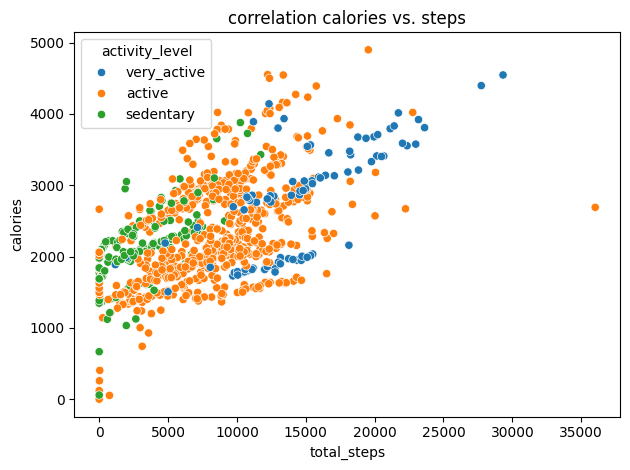

In [23]:
# share
# correlation between steps and calories burned

ax = sns.scatterplot(x='total_steps', y='calories',data=df, hue=df['activity_level'])

plt.title('correlation calories vs. steps')

plt.tight_layout()
plt.show()

In the scatter plot below, we can observe a moderately positive correlation: the greater the number of steps taken, the higher the number of calories burned. Additionally, I colored the data points according to the 'activity_level' category, allowing us to identify which group each set of observations belongs to.

Average Daily Steps

What is the average number of steps taken per day?

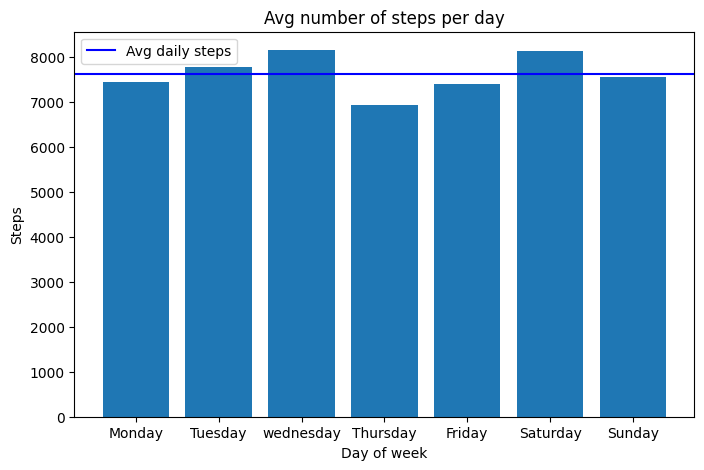

In [24]:
# average steps per day

day_of_week = ['Monday', 'Tuesday', 'wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
fig, ax = plt.subplots(1,1, figsize=(8,5))

day_grp = df.groupby(['day_of_week'])
avg_daily_steps = day_grp['total_steps'].mean()
avg_steps = df['total_steps'].mean()

plt.bar(avg_daily_steps.index, avg_daily_steps)

ax.set_xticks(range(len(day_of_week)))
ax.set_xticklabels(day_of_week)

ax.axhline(y=avg_daily_steps.mean(), color='blue',label='Avg daily steps')

ax.set_ylabel('Steps')
ax.set_xlabel('Day of week')
ax.set_title('Avg number of steps per day')
plt.legend()
plt.show()

The results indicate that Tuesday, Wednesday, and Saturday are the days on which users record the highest levels of physical activity, as the average number of steps on these days exceeds the overall mean. In contrast, Monday, Friday, and Sunday have average step counts below the overall average and exhibit very similar patterns. Thursday stands out as the day with the lowest level of physical activity.

Based on these results, it can be inferred that users tend to be more active during the middle of the week and on Saturdays. This pattern may be related to their daily routines, such as exercise habits, work schedules, or recreational activities.


Percentage of Activity Time

What percentage of the time are people active?


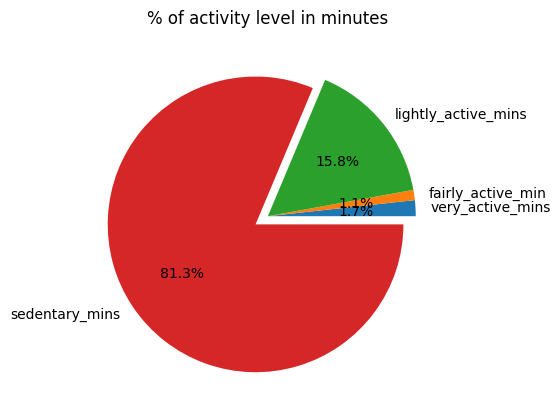

In [25]:
#porcentage of activity in minutes

very_active_mins = df['very_active_minutes'].sum()
fairly_active_min = df['fairly_active_minutes'].sum()
lightly_active_mins = df['lightly_active_minutes'].sum()
sedentary_mins = df['sedentary_minutes'].sum()

slices = [very_active_mins, fairly_active_min, lightly_active_mins, sedentary_mins]

labels = ['very_active_mins', 'fairly_active_min', 'lightly_active_mins', 'sedentary_mins']

explode = [0,0,0,0.1]

plt.pie(slices, labels=labels, explode = explode, autopct = '%1.1f%%')

plt.title('% of activity level in minutes')
plt.show()

The pie chart indicates that users spend most of their time in a sedentary state. Only about one-sixth of their time is spent performing light physical activity, and just 2% of the time is dedicated to higher-intensity physical activity or exercise. These results suggest that the overall physical activity level of the users is low, with sedentary behavior accounting for the majority of their time.


Correlation Between Activity-Level Minutes and Calories:


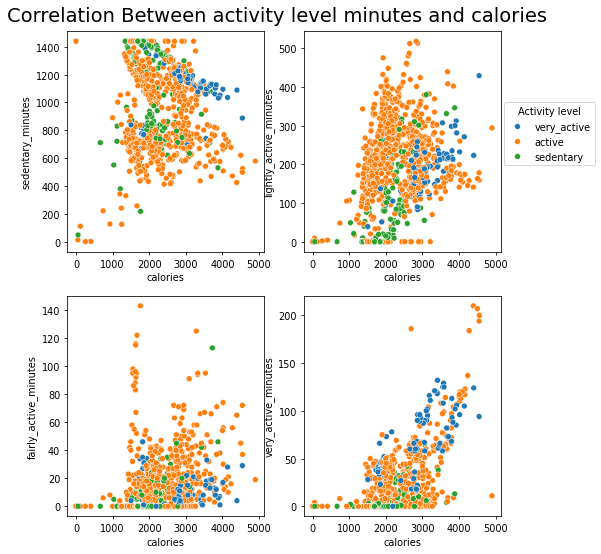

In [26]:
# correlation between activity level in minutes and calories

n_day_of_week = [0,1,2,3,4,5,6,]

fig, axes = plt.subplots(nrows=2, ncols=2,figsize=(8,9), dpi=70)

sns.scatterplot(data=df, x='calories', y='sedentary_minutes', hue='activity_level', ax=axes[0,0], legend=False)
sns.scatterplot(data=df, x='calories', y='lightly_active_minutes', hue='activity_level', ax=axes[0,1], legend=False)
sns.scatterplot(data=df, x='calories', y='fairly_active_minutes', hue='activity_level', ax=axes[1,0], legend=False)
sns.scatterplot(data=df, x='calories', y='very_active_minutes', hue='activity_level', ax=axes[1,1], legend=True)

plt.legend(title= 'Activity level', bbox_to_anchor = (1.5,1.9))

fig.suptitle('Correlation Between activity level minutes and calories',x=0.5,y=0.92, fontsize=20)

plt.show()

# 6. Act


After analyzing the Fitbit fitness tracker data, several conclusions were drawn that can help strengthen Bellabeat's marketing strategy.

A Device for Everyday Life

Bellabeat can communicate more clearly that its products are not designed exclusively for exercise or sports. The data show that many people use the device for longer periods on weekends than on weekdays, which may indicate that they consider it useful only for recreational or sports-related activities. The company can emphasize that its devices are designed to accompany users throughout the day, whether at work, at home, or during their daily routines, allowing them to continuously monitor their health and well-being. This approach can attract women with different lifestyles and interests who are looking to improve their overall health.

Motivation Through Incentives and Notifications

Bellabeat could also incorporate features that help keep users motivated to achieve their health goals. For example, the app could offer rewards for reaching milestones such as walking at least 7,000 steps per day, burning a certain number of calories, or sleeping around 8 hours each night. These rewards could include digital badges, positions on a user leaderboard, or exclusive promotions and discounts. In addition, the app could send reminders when it detects that a user is falling behind on their goals and provide personalized suggestions to help improve their physical activity and sleep habits.